In [2]:
import xarray as xr

In [33]:
def seasonality(data):
    return data.groupby('time.season').mean(dim='time')

In [3]:
ds = xr.open_dataset('../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc')
ds.temp

<xarray.DataArray 'temp' (time: 1, s_rho: 32, eta_rho: 542, xi_rho: 602)> Size: 42MB
[10441088 values with dtype=float32]
Coordinates:
  * xi_rho   (xi_rho) float64 5kB 1.0 2.0 3.0 4.0 ... 599.0 600.0 601.0 602.0
  * eta_rho  (eta_rho) float64 4kB 1.0 2.0 3.0 4.0 ... 539.0 540.0 541.0 542.0
  * s_rho    (s_rho) float64 256B -0.9844 -0.9531 -0.9219 ... -0.04688 -0.01562
    lon_rho  (eta_rho, xi_rho) float64 3MB ...
    lat_rho  (eta_rho, xi_rho) float64 3MB ...
  * time     (time) float32 4B 1.339e+06
Attributes:
    long_name:      averaged potential temperature
    units:          Celsius
    field:          temperature, scalar, series
    standard_name:  sea_water_potential_temperature

In [4]:
from pathlib import Path
import re
import numpy as np
import xarray as xr

# --- Files and times ---
files = sorted(Path("../../NHCS/hincast_1980-2015/").glob("croco_avg_Y*M*.nc"))

def extract_datetime_from_filename(path):
    match = re.search(r"Y(\d{4})M(\d{2})", path.name)
    if match:
        year = int(match.group(1))
        month = int(match.group(2))
        return np.datetime64(f"{year}-{month:02d}")
    else:
        raise ValueError(f"Fecha no encontrada en nombre: {path.name}")

time_values = [extract_datetime_from_filename(f) for f in files]


In [ ]:
def load_temp_depths(path, time_val, depths):
    time_val = np.datetime64(time_val, 'ns')
    ds = xr.open_dataset(path, chunks={"time": 1})

    # --- Depth computation ---
    h      = ds['h'].values
    hc     = float(ds['hc'].values)
    Cs_r   = ds['Cs_r'].values
    s_rho  = ds['s_rho'].values
    vtrans = int(ds['Vtransform'].values)

    if vtrans == 1:
        z = (hc * s_rho[:, None, None]
             + (h[None, :, :] - hc) * Cs_r[:, None, None])
    elif vtrans == 2:
        z = ((hc * s_rho[:, None, None] + h[None, :, :] * Cs_r[:, None, None])
             / (hc + h[None, :, :])
             * h[None, :, :])

    temp = ds['temp'].isel(time=0).values   # (s_rho, eta_rho, xi_rho)
    ny, nx = h.shape
    jj, ii = np.meshgrid(np.arange(ny), np.arange(nx), indexing='ij')

    # --- Extract all depths into a 3D array (depth, eta_rho, xi_rho) ---
    stack = np.full((len(depths), ny, nx), np.nan, dtype=np.float32)

    for k, d in enumerate(depths):
        idx = np.argmin(np.abs(z - (-float(d))), axis=0)
        field = temp[idx, jj, ii].astype(np.float32)
        field[h < d] = np.nan
        stack[k] = field

    # --- Wrap as DataArray with depth dim ---
    lon_1d = ds['lon_rho'].isel(eta_rho=0).values
    lat_1d = ds['lat_rho'].isel(xi_rho=0).values

    temp_da = xr.DataArray(
        stack,
        dims=['depth', 'lat', 'lon'],
        coords={
            'depth': depths,
            'lat':   lat_1d,
            'lon':   lon_1d,
        },
        attrs={'long_name': 'Temperature', 'units': 'Celsius'}
    )

    return temp_da.expand_dims(time=[time_val])


# --- Run ---
depths = [5] + list(range(10, 101, 10)) + list(range(120, 301, 20))

from tqdm.notebook import tqdm

temp_list = [load_temp_depths(f, t, depths) for f, t in tqdm(zip(files, time_values), total=len(files), desc="Loading temp depths")]
temp_all = xr.concat(temp_list, dim="time")

print(temp_all)

In [ ]:
# temp_all.to_dataset(name='temp').to_netcdf('Temp.nc')

## Temperature Surface up to the MLD

In [9]:
import numpy as np
import xarray as xr
from numba import njit
from tqdm.notebook import tqdm

@njit
def extract_temp_surface_to_mld(var_3d, z_3d, mld_depths, out_depths, out):
    """
    For each (j,i): extract temperature at fixed `out_depths`
    using nearest sigma level, masked below MLD.

    var_3d:     (nz, ny, nx)   - temperature on sigma levels
    z_3d:       (nz, ny, nx)   - depth of sigma levels (negative)
    mld_depths: (ny, nx)       - MLD in positive meters
    out_depths: (nd,)          - target depths in positive meters
    out:        (nd, ny, nx)   - output array, pre-filled with nan
    """
    nz, ny, nx = var_3d.shape
    nd = out_depths.shape[0]

    for j in range(ny):
        for i in range(nx):
            mld = mld_depths[j, i]
            z_col = z_3d[:, j, i]
            T_col = var_3d[:, j, i]

            for d in range(nd):
                # Skip if this depth is below the MLD
                if out_depths[d] > mld:
                    continue

                # Nearest sigma level (same as CROCO winterp_mld.m)
                min_val = 1e30
                nearest_k = 0
                for k in range(nz):
                    diff = abs(abs(z_col[k]) - out_depths[d])
                    if diff < min_val:
                        min_val = diff
                        nearest_k = k
                out[d, j, i] = T_col[nearest_k]


def load_temp_surface_to_mld(path, time_val, depths):
    """
    Extract temperature on fixed depth levels, masked below the MLD.
    Uses nearest sigma level (consistent with CROCO tools).

    Returns DataArray (time, depth, lat, lon) with NaN below MLD.
    """
    time_val = np.datetime64(time_val, 'ns')
    ds = xr.open_dataset(path, chunks={"time": 1})

    # --- Sigma-level depths ---
    h      = ds['h'].values
    hc     = float(ds['hc'].values)
    Cs_r   = ds['Cs_r'].values
    s_rho  = ds['s_rho'].values
    vtrans = int(ds['Vtransform'].values)

    if vtrans == 1:
        z = (hc * s_rho[:, None, None]
             + (h[None, :, :] - hc) * Cs_r[:, None, None])
    elif vtrans == 2:
        z = ((hc * s_rho[:, None, None] + h[None, :, :] * Cs_r[:, None, None])
             / (hc + h[None, :, :])
             * h[None, :, :])

    # --- Load fields ---
    temp = ds['temp'].isel(time=0).values    # (nz, ny, nx)
    hbl  = ds['hbl'].isel(time=0).values    # (ny, nx) — MLD in positive meters

    ny, nx = h.shape
    out_depths = np.array(depths, dtype=np.float64)
    out = np.full((len(depths), ny, nx), np.nan, dtype=np.float64)

    # --- Fill with numba ---
    extract_temp_surface_to_mld(
        temp.astype(np.float64),
        z.astype(np.float64),
        hbl.astype(np.float64),
        out_depths,
        out,
    )

    # Extra mask: where bathymetry is shallower than target depth
    for k, d in enumerate(depths):
        out[k][h < d] = np.nan

    # --- Wrap ---
    lon_1d = ds['lon_rho'].isel(eta_rho=0).values
    lat_1d = ds['lat_rho'].isel(xi_rho=0).values
    ds.close()

    da = xr.DataArray(
        out.astype(np.float32),
        dims=['depth', 'lat', 'lon'],
        coords={'depth': out_depths, 'lat': lat_1d, 'lon': lon_1d},
        attrs={'long_name': 'Temperature (surface to MLD)', 'units': 'Celsius'}
    )
    return da.expand_dims(time=[time_val])


# --- Depths to extract (tune upper limit to your typical MLD range) ---
depths = [0, 5] + list(range(10, 51, 5)) + list(range(60, 101, 10))

# --- Run ---
temp_surf_mld_list = [
    load_temp_surface_to_mld(f, t, depths)
    for f, t in tqdm(zip(files, time_values), total=len(files),
                     desc="Temp surface→MLD")
]
temp_surf_mld_all = xr.concat(temp_surf_mld_list, dim="time")
print(temp_surf_mld_all)

Temp surface→MLD:   0%|          | 0/432 [00:00<?, ?it/s]

<xarray.DataArray (time: 432, depth: 16, lat: 542, lon: 602)> Size: 9GB
array([[[[20.187956, 20.176714, 20.24205 , ...,  0.      ,  0.      ,
           0.      ],
         [20.1992  , 20.289068, 20.375937, ...,  0.      ,  0.      ,
           0.      ],
         [20.23746 , 20.348139, 20.458187, ...,  0.      ,  0.      ,
           0.      ],
         ...,
         [26.64544 , 26.665993, 26.61425 , ...,  0.      ,  0.      ,
           0.      ],
         [26.64165 , 26.67271 , 26.637682, ...,  0.      ,  0.      ,
           0.      ],
         [26.64862 , 26.65559 , 26.628126, ...,  0.      ,  0.      ,
           0.      ]],

        [[      nan,       nan,       nan, ...,       nan,       nan,
                nan],
         [      nan,       nan,       nan, ...,       nan,       nan,
                nan],
         [      nan,       nan,       nan, ...,       nan,       nan,
                nan],
...
         [      nan,       nan,       nan, ...,       nan,       nan,
          

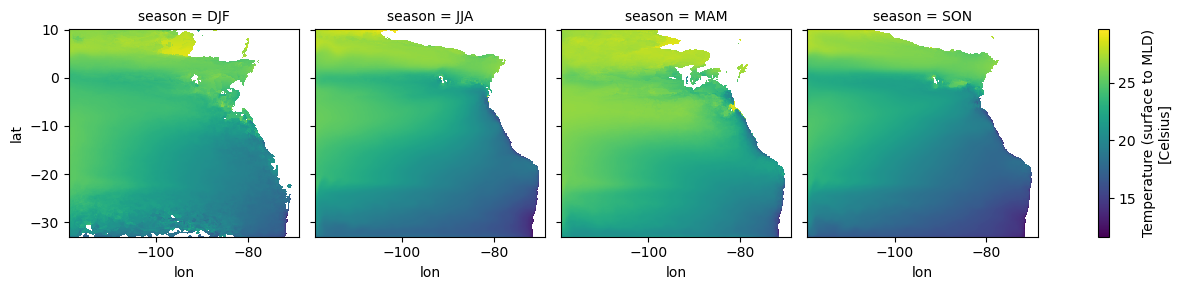

In [35]:
seasonality(temp_surf_mld_all).sel(depth=30).plot(x='lon',y='lat',col='season')

In [38]:
depths_arr = temp_surf_mld_all.depth.values

# Layer thickness: distance between midpoints (same logic as np.gradient)
thickness = xr.DataArray(
    np.gradient(depths_arr),
    dims='depth',
    coords={'depth': depths_arr}
)

temp_wmean = temp_surf_mld_all.weighted(thickness).mean(dim='depth')
temp_wmean = temp_wmean.where(temp_wmean!=0)
temp_wmean

<xarray.DataArray (time: 432, lat: 542, lon: 602)> Size: 1GB
array([[[20.18795586, 20.17671394, 20.24205017, ...,  0.        ,
          0.        ,  0.        ],
        [20.19919968, 20.28906822, 20.37593651, ...,  0.        ,
          0.        ,  0.        ],
        [20.23745918, 20.34813881, 20.4581871 , ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [26.77448368, 26.66632811, 26.61077118, ...,  0.        ,
          0.        ,  0.        ],
        [26.74240653, 26.67430337, 26.63964844, ...,  0.        ,
          0.        ,  0.        ],
        [26.74024232, 26.73807748, 26.73452473, ...,  0.        ,
          0.        ,  0.        ]],

       [[22.13241005, 22.10890675, 22.10158825, ...,  0.        ,
          0.        ,  0.        ],
        [22.15591431, 22.09944312, 22.06870143, ...,  0.        ,
          0.        ,  0.        ],
        [22.19230461, 22.11490091, 22.06467787, ...,  0.        ,
          0.        ,  0.        ],
...
        [28.98026625, 28.97930527, 28.97612127, ...,  0.        ,
          0.        ,  0.        ],
        [28.9966472 , 28.99245358, 28.99222151, ...,  0.        ,
          0.        ,  0.        ],
        [28.99682744, 28.99700769, 29.00067107, ...,  0.        ,
          0.        ,  0.        ]],

       [[18.12901433, 18.13570595, 18.12791189, ...,  0.        ,
          0.        ,  0.        ],
        [18.12232335, 18.16763624, 18.15278498, ...,  0.        ,
          0.        ,  0.        ],
        [18.15290324, 18.19544983, 18.18537521, ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [28.82737112, 28.46759868, 28.48139405, ...,  0.        ,
          0.        ,  0.        ],
        [28.88208103, 28.56843233, 28.60427594, ...,  0.        ,
          0.        ,  0.        ],
        [28.77572393, 28.66936636, 28.83566642, ...,  0.        ,
          0.        ,  0.        ]]])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-01 1980-02-01 ... 2015-12-01
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87

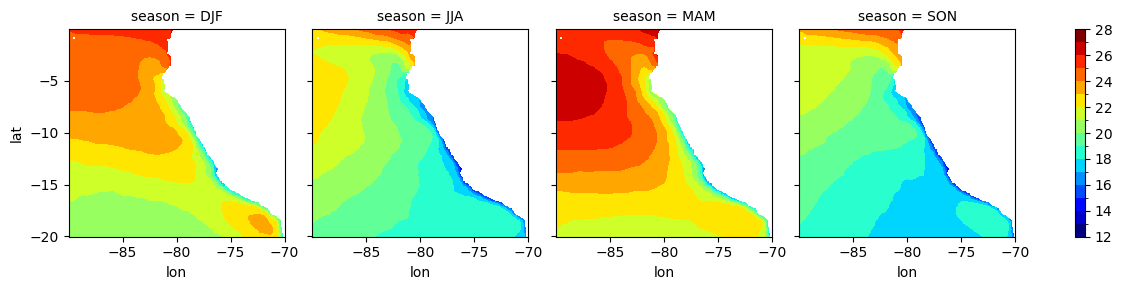

In [44]:
seasonality(temp_wmean).sel(
    lat=slice(-20,0),lon=slice(-90,-70)).plot(x='lon',y='lat',col='season',vmin=12,vmax=28,levels=17,cmap='jet')

In [45]:
# temp_wmean.rename('Temp').to_dataset().to_netcdf('Temp_0_mld.nc')

## Temp at the MLD

In [14]:
import numpy as np
import xarray as xr
from numba import njit

# ─── Direct translation of winterp_mld.m (with numba for speed) ───

@njit
def interp_mld(var_3d, z_3d, mld_depths):
    """
    Exact translation of winterp_mld.m
    var_3d:     (nz, ny, nx)
    z_3d:       (nz, ny, nx)
    mld_depths: (ny, nx)
    """
    nz, ny, nx = var_3d.shape
    result = np.full((ny, nx), np.nan)

    for j in range(ny):
        for i in range(nx):
            var_profile = var_3d[:, j, i]
            z_profile   = z_3d[:, j, i]

            # Find nearest level: min(abs(abs(z_profile) - mld_depths(j,i)))
            min_val = 1e30
            nearest_level = 0
            for k in range(nz):
                diff = abs(abs(z_profile[k]) - mld_depths[j, i])
                if diff < min_val:
                    min_val = diff
                    nearest_level = k

            result[j, i] = var_profile[nearest_level]

    return result


# ─── Full loader ───────────────────────────────────────────────

def load_temp_mld(path, time_val):
    time_val = np.datetime64(time_val, 'ns')
    ds = xr.open_dataset(path, chunks={"time": 1})

    # --- Depth computation ---
    h      = ds['h'].values
    hc     = float(ds['hc'].values)
    Cs_r   = ds['Cs_r'].values
    s_rho  = ds['s_rho'].values
    vtrans = int(ds['Vtransform'].values)

    if vtrans == 1:
        z = (hc * s_rho[:, None, None]
             + (h[None, :, :] - hc) * Cs_r[:, None, None])
    elif vtrans == 2:
        z = ((hc * s_rho[:, None, None] + h[None, :, :] * Cs_r[:, None, None])
             / (hc + h[None, :, :])
             * h[None, :, :])

    # --- Temperature and MLD ---
    temp = ds['temp'].isel(time=0).values       # (s_rho, eta_rho, xi_rho)
    hbl  = ds['hbl'].isel(time=0).values        # (eta_rho, xi_rho)

    # --- Extract at MLD using your MATLAB logic ---
    field = interp_mld(temp, z, hbl).astype(np.float32)

    # Mask where bottom is shallower than MLD
    field[h < hbl] = np.nan

    # --- Wrap as DataArray ---
    lon_1d = ds['lon_rho'].isel(eta_rho=0).values
    lat_1d = ds['lat_rho'].isel(xi_rho=0).values

    temp_da = xr.DataArray(
        field,
        dims=['lat', 'lon'],
        coords={'lat': lat_1d, 'lon': lon_1d},
        attrs={'long_name': 'Temperature at MLD', 'units': 'Celsius'}
    )
    ds.close()
    return temp_da.expand_dims(time=[time_val])


# ─── Run ───────────────────────────────────────────────────────
from tqdm.notebook import tqdm

temp_mld_list = [load_temp_mld(f, t)
                 for f, t in tqdm(zip(files, time_values),
                                  total=len(files),
                                  desc="Loading temp at MLD")]
temp_mld_all = xr.concat(temp_mld_list, dim="time")
print(temp_mld_all)

Loading temp at MLD:   0%|          | 0/432 [00:00<?, ?it/s]

<xarray.DataArray (time: 432, lat: 542, lon: 602)> Size: 564MB
array([[[20.187956, 20.176714, 20.24205 , ...,  0.      ,  0.      ,
          0.      ],
        [20.1992  , 20.289068, 20.375937, ...,  0.      ,  0.      ,
          0.      ],
        [20.23746 , 20.348139, 20.458187, ...,  0.      ,  0.      ,
          0.      ],
        ...,
        [26.779615, 26.63109 , 26.594152, ...,  0.      ,  0.      ,
          0.      ],
        [26.733833, 26.634449, 26.624374, ...,  0.      ,  0.      ,
          0.      ],
        [26.72419 , 26.714546, 26.785486, ...,  0.      ,  0.      ,
          0.      ]],

       [[22.06243 , 22.012548, 22.05573 , ...,  0.      ,  0.      ,
          0.      ],
        [22.11231 , 21.978964, 21.938076, ...,  0.      ,  0.      ,
          0.      ],
        [22.161886, 21.983593, 21.899609, ...,  0.      ,  0.      ,
          0.      ],
...
        [29.015074, 28.984451, 28.97917 , ...,  0.      ,  0.      ,
          0.      ],
        [29.025131

In [15]:
def seasonality(data):
    return data.groupby('time.season').mean(dim='time')

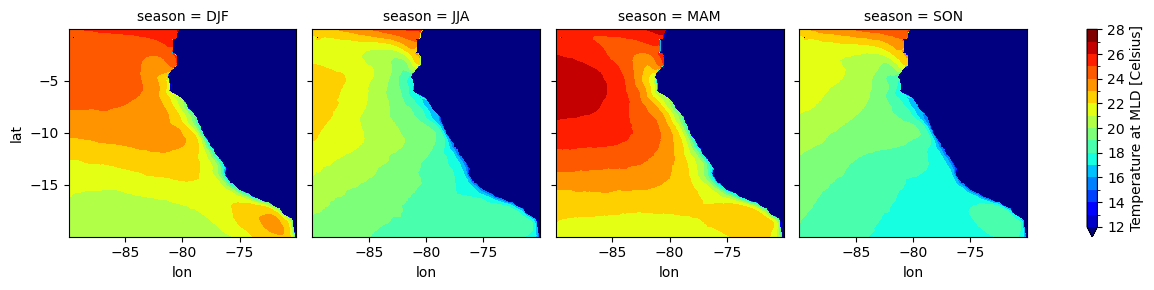

In [18]:
seasonality(temp_mld_all).sel(
    lat=slice(-20,0),lon=slice(-90,-70)).plot.contourf(x="lon", y="lat", vmin=12,vmax=28,levels=17,col="season", cmap='jet')
